# 🐍 Python Data Analysis

# Netflix Movies & TV Shows Analysis

**Author:** Lalitha Devi Seri

---

## Project Overview

This project analyzes the Netflix Movies & TV Shows dataset using Python to explore content distribution, release trends, genres, ratings, and countries. The analysis demonstrates data cleaning, exploratory data analysis (EDA), and visualization techniques to generate meaningful business insights.

## Business Objective

The objective of this project is to analyze Netflix's content library and answer key business questions, including:

- What type of content is most common?
- Which countries produce the most content?
- How has Netflix's content grown over time?
- What are the most common content ratings?
- Which genres dominate the platform?

The findings help understand content distribution and support business decision-making.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [3]:
import pandas as pd

df = pd.read_csv("Netflix Movies and TV Shows.csv")

print("Dataset Loaded Successfully!")
print(df.shape)

Dataset Loaded Successfully!
(8807, 12)


# Data Understanding

The Netflix Movies and TV Shows dataset contains information about titles available on Netflix, including movies and TV shows, release years, countries, ratings, durations, directors, cast, and genres.

Understanding the dataset structure helps identify data types, missing values, and data quality before performing analysis.

In [4]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 447.3 KB


In [6]:
df.describe(include="all")

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8804,4528,7692,748,1767,NaN,17,220,514,8775
top,s1,Movie,15-Aug,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,2,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


In [7]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 8807
Columns : 12


In [8]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

In [9]:
df.dtypes

show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object

# Data Cleaning

This step identifies missing values, duplicate records, and prepares the dataset for analysis by converting data types where necessary.

In [10]:
df.isnull().sum().sort_values(ascending=False)

director        2634
country          831
cast             825
date_added        10
rating             4
duration           3
show_id            0
type               0
title              0
release_year       0
listed_in          0
description        0
dtype: int64

In [11]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [12]:
df.drop_duplicates(inplace=True)

print("Rows after removing duplicates :", df.shape[0])

Rows after removing duplicates : 8807


In [14]:
df["date_added"] = pd.to_datetime(
    df["date_added"],
    format="mixed",
    errors="coerce"
)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   str           
 1   type          8807 non-null   str           
 2   title         8807 non-null   str           
 3   director      6173 non-null   str           
 4   cast          7982 non-null   str           
 5   country       7976 non-null   str           
 6   date_added    8797 non-null   datetime64[us]
 7   release_year  8807 non-null   int64         
 8   rating        8803 non-null   str           
 9   duration      8804 non-null   str           
 10  listed_in     8807 non-null   str           
 11  description   8807 non-null   str           
dtypes: datetime64[us](1), int64(1), str(10)
memory usage: 481.7 KB


# Exploratory Data Analysis (EDA)

This section explores the Netflix dataset using visualizations to identify trends, patterns, and business insights.

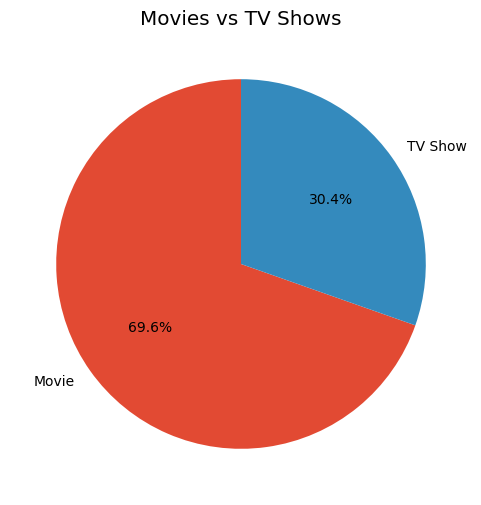

In [15]:
content_type = df["type"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    content_type,
    labels=content_type.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Movies vs TV Shows")
plt.show()

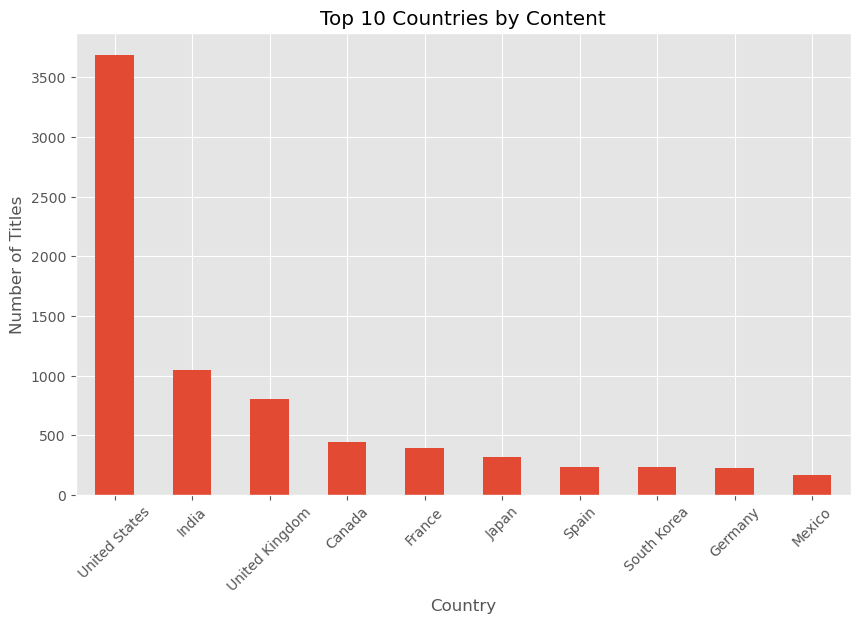

In [16]:
country = (
    df["country"]
    .dropna()
    .str.split(", ")
    .explode()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,6))
country.plot(kind="bar")

plt.title("Top 10 Countries by Content")
plt.xlabel("Country")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)
plt.show()

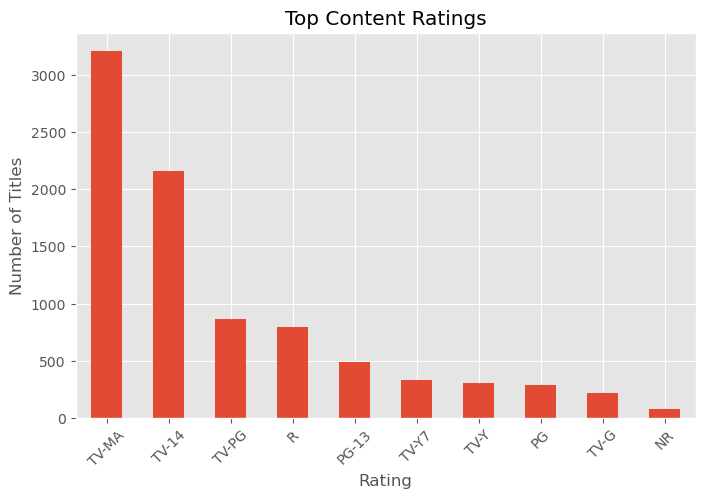

In [17]:
rating = df["rating"].value_counts().head(10)

plt.figure(figsize=(8,5))
rating.plot(kind="bar")

plt.title("Top Content Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)
plt.show()

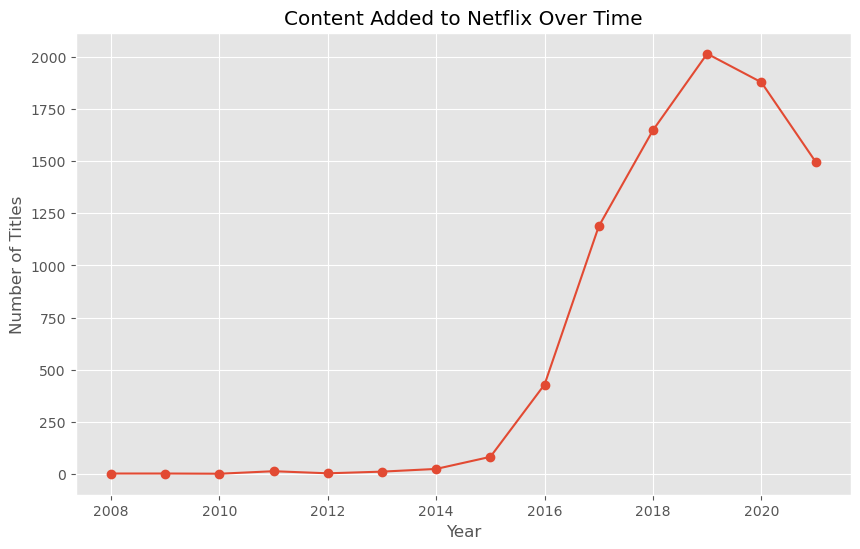

In [18]:
df["year_added"] = df["date_added"].dt.year

year_added = df["year_added"].value_counts().sort_index()

plt.figure(figsize=(10,6))
year_added.plot(kind="line", marker="o")

plt.title("Content Added to Netflix Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Titles")

plt.show()

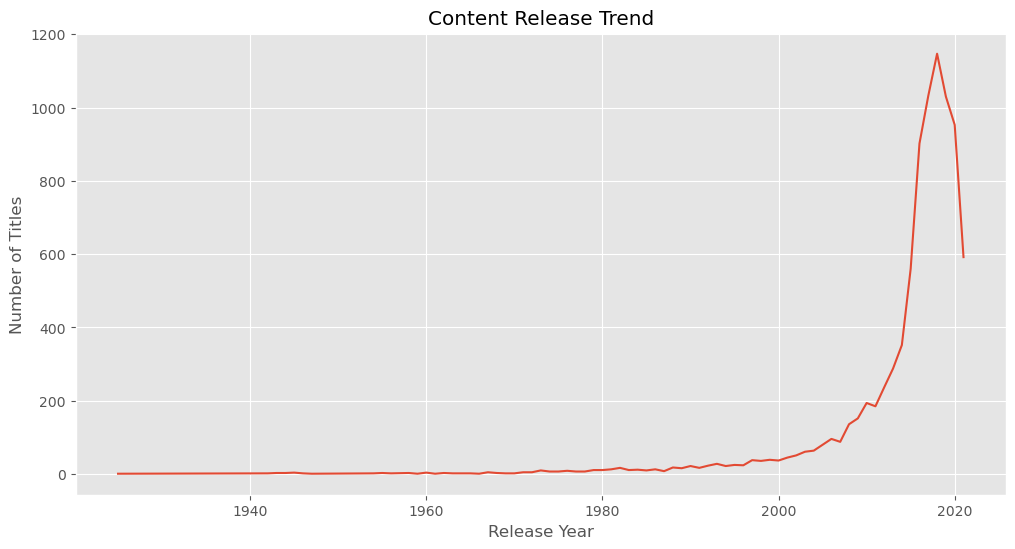

In [19]:
release = df["release_year"].value_counts().sort_index()

plt.figure(figsize=(12,6))
release.plot(kind="line")

plt.title("Content Release Trend")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.show()

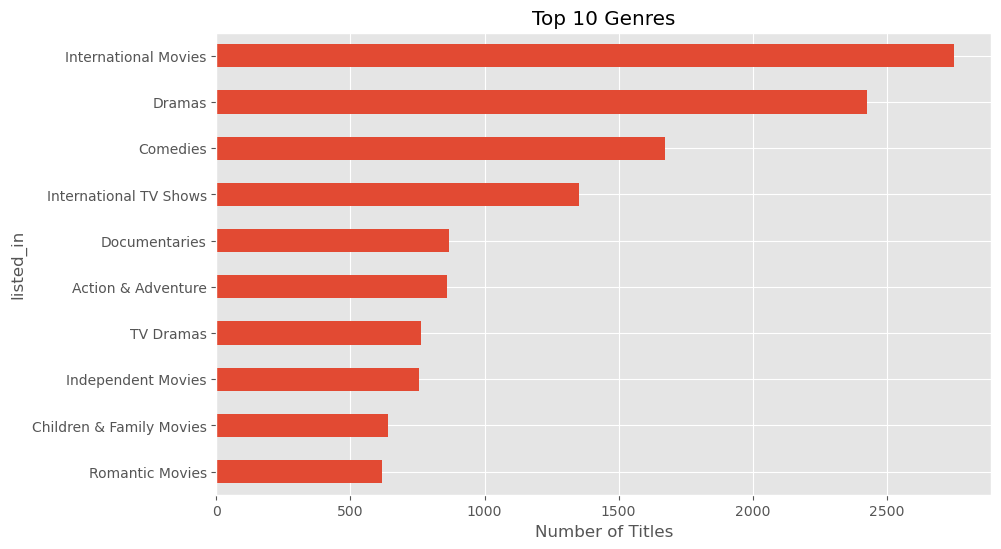

In [20]:
genres = (
    df["listed_in"]
    .str.split(", ")
    .explode()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,6))
genres.plot(kind="barh")

plt.title("Top 10 Genres")
plt.xlabel("Number of Titles")

plt.gca().invert_yaxis()
plt.show()

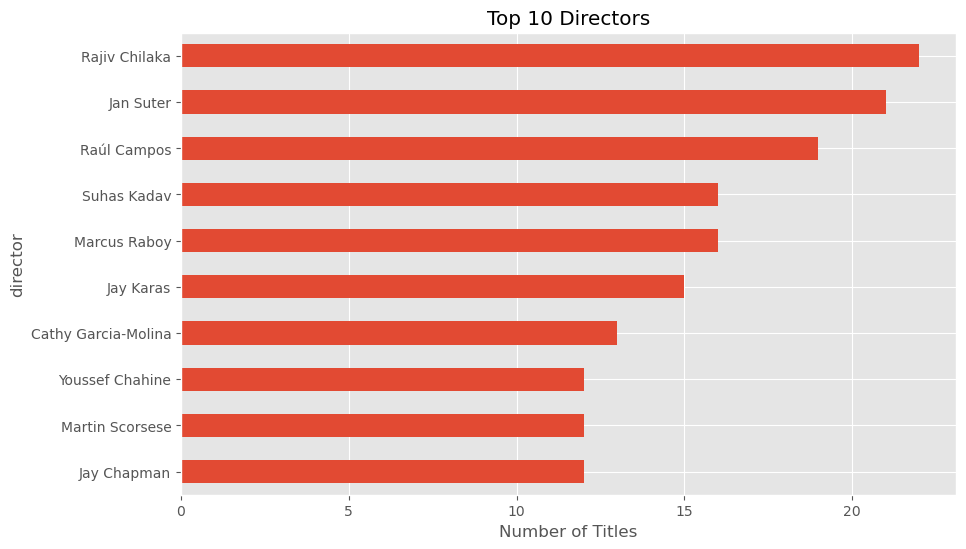

In [21]:
directors = (
    df["director"]
    .dropna()
    .str.split(", ")
    .explode()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,6))
directors.plot(kind="barh")

plt.title("Top 10 Directors")
plt.xlabel("Number of Titles")

plt.gca().invert_yaxis()
plt.show()

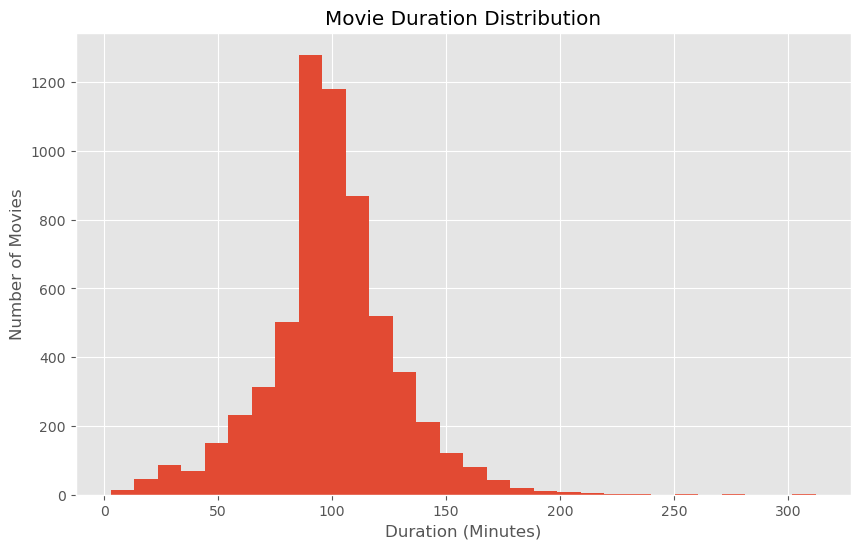

In [23]:
# Filter only Movies
movies = df[df["type"] == "Movie"].copy()

# Remove ' min' and convert to numeric
movies["duration"] = (
    movies["duration"]
    .str.replace(" min", "", regex=False)
)

movies["duration"] = pd.to_numeric(movies["duration"], errors="coerce")

plt.figure(figsize=(10,6))
plt.hist(movies["duration"].dropna(), bins=30)

plt.title("Movie Duration Distribution")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Movies")

plt.show()

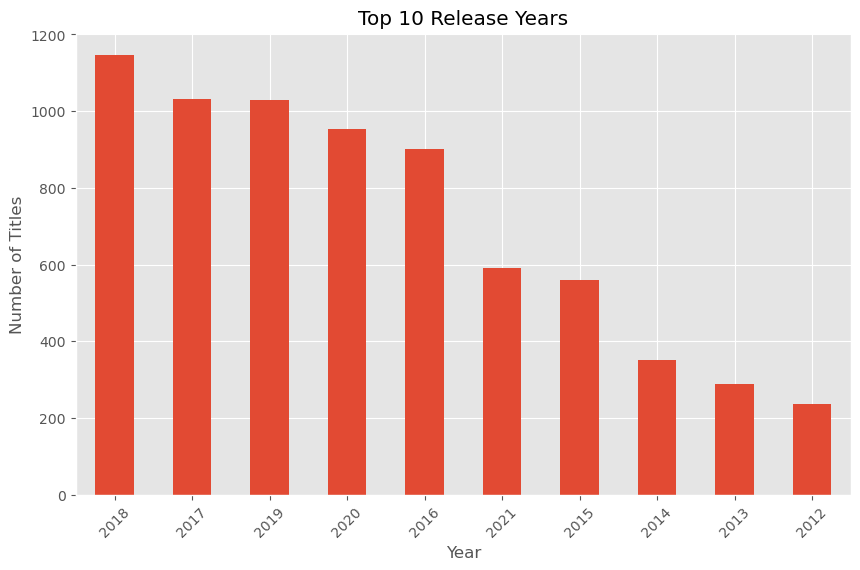

In [24]:
top_years = df["release_year"].value_counts().head(10)

plt.figure(figsize=(10,6))
top_years.plot(kind="bar")

plt.title("Top 10 Release Years")
plt.xlabel("Year")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)
plt.show()

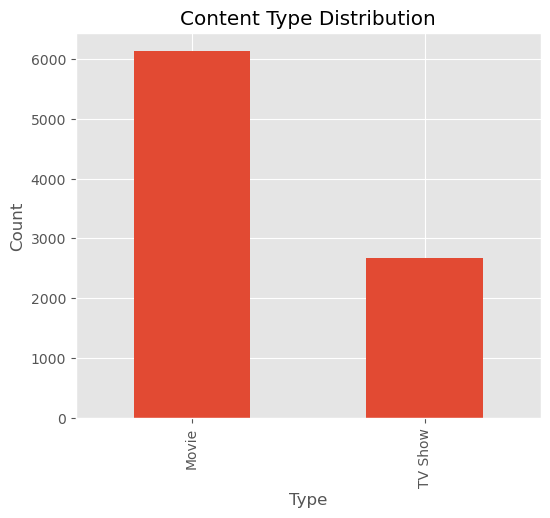

In [25]:
type_count = df["type"].value_counts()

plt.figure(figsize=(6,5))
type_count.plot(kind="bar")

plt.title("Content Type Distribution")
plt.xlabel("Type")
plt.ylabel("Count")

plt.show()

# Key Insights

In [26]:
print("""
Key Insights

• Movies significantly outnumber TV Shows on Netflix.

• The United States contributes the largest share of Netflix content.

• TV-MA is the most common content rating.

• Netflix experienced rapid content growth after 2015.

• International Movies and Dramas are among the most common genres.

• A small number of directors have contributed multiple titles to the platform.

• Most movies have a duration between 80 and 120 minutes.

• Recent years contain the highest number of content releases.
""")


Key Insights

• Movies significantly outnumber TV Shows on Netflix.

• The United States contributes the largest share of Netflix content.

• TV-MA is the most common content rating.

• Netflix experienced rapid content growth after 2015.

• International Movies and Dramas are among the most common genres.

• A small number of directors have contributed multiple titles to the platform.

• Most movies have a duration between 80 and 120 minutes.

• Recent years contain the highest number of content releases.



# Recommendations

In [27]:
print("""
Recommendations

• Continue expanding international content.

• Increase investment in successful genres.

• Focus on acquiring high-performing TV series.

• Maintain a balanced content library across ratings and age groups.

• Monitor release trends to optimize future content strategies.
""")


Recommendations

• Continue expanding international content.

• Increase investment in successful genres.

• Focus on acquiring high-performing TV series.

• Maintain a balanced content library across ratings and age groups.

• Monitor release trends to optimize future content strategies.



# Conclusion

In [28]:
print("""
Conclusion

This analysis explored the Netflix Movies and TV Shows dataset using Python to identify trends in content distribution, genres, countries, ratings, and release patterns.

The project demonstrates data cleaning, exploratory data analysis (EDA), and visualization techniques that support data-driven business decision-making.
""")


Conclusion

This analysis explored the Netflix Movies and TV Shows dataset using Python to identify trends in content distribution, genres, countries, ratings, and release patterns.

The project demonstrates data cleaning, exploratory data analysis (EDA), and visualization techniques that support data-driven business decision-making.

